# Hotel Booking Cancellation Prediction

**Data source:** Kaggle (https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

**Business Goal:** Create a machine learning model capable of predicting whether a customer will cancel their reservation (Class 1) or arrive at the hotel (Class 0). This allows the hotel to optimize revenue, manage overbooking, and tailor cancellation policies.

**Algorithms used:** PCA, t-SNE, Logistic Regression, k-NN, SVM

### Importing libraries

In [27]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from yellowbrick.classifier import PrecisionRecallCurve
from yellowbrick.classifier import ROCAUC
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier

## Loading data

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/hotel_bookings.csv')
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [3]:
data.drop(columns=["reservation_status_date"], axis=1, inplace=True)
data.drop(columns=["reservation_status"], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
data.is_canceled.value_counts(normalize=True)

,proportion
is_canceled,
0,0.629584
1,0.370416


## Missing data

In [5]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)
missing_data[:5]

,missing value,percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
lead_time,0,0.000000


Note: The 'company' column has over 94% missing values. Since it lacks sufficient data to provide meaningful patterns for our model, we drop it entirely from the dataset.

In [6]:
data = data.drop(columns=['company'])

Since 'children', and 'country' represent discrete or categorical concepts, filling missing values with the mean would not make sense (e.g., 1.5 children). Therefore, we use the mode (the most frequent value) for imputation.

In [7]:
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['agent'] = data['agent'].fillna(0)
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


**Mapping and One-Hot Encoding**: Machine learning models require numerical input. For ordinal features (where there is a natural hierarchy, like room types or meal plans), we map them directly to integers. For nominal features (like 'market_segment' or 'country', where no category is mathematically "greater" than another), we use One-Hot Encoding (pd.get_dummies).

*Note: We grouped countries outside the top 10 into an 'Other' category to prevent our dataset from expanding into hundreds of sparse, uninformative columns.*

In [8]:
meal_map = {'Undefined': 0, 'SC': 0, 'BB': 1, 'HB': 2, 'FB': 3}
data['meal'] = data['meal'].map(meal_map)
room_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'L': 9, 'P': 10}
data['assigned_room_type'] = data['assigned_room_type'].map(room_map)
data['reserved_room_type'] = data['reserved_room_type'].map(room_map)


In [9]:
top_10_countries = data['country'].value_counts().nlargest(10).index

data['country'] = data['country'].apply(lambda x: x if x in top_10_countries else 'Other')

In [10]:
data['has_agent'] = np.where(data['agent'] == 0, 0, 1)
data = data.drop(columns=['agent'])

In [11]:
data['assigned_room_type'] = data['assigned_room_type'].fillna(data['assigned_room_type'].mode()[0])

In [12]:
c = [
    'arrival_date_month',
    'hotel',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type',
    'country'
]

data = pd.get_dummies(data, columns=c, drop_first=True)

In [13]:
data.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,False,True
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,False,True
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,True,False,False,False,False,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False


## Outliers

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


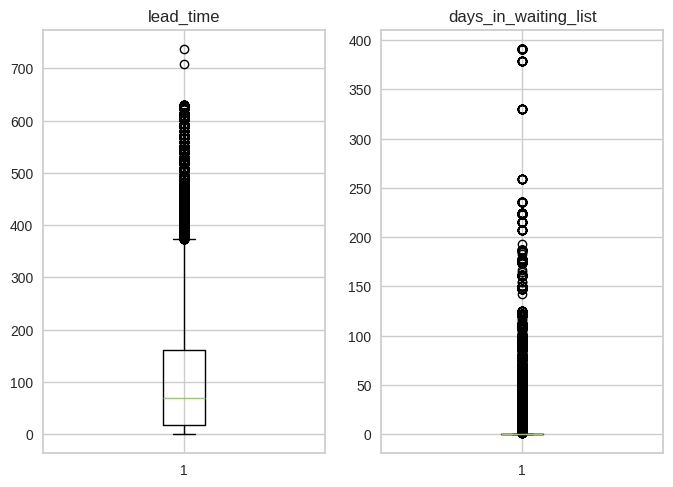

In [15]:
plt.subplot(1, 2, 1)
plt.boxplot(x=data['lead_time'])
plt.title('lead_time')
plt.subplot(1, 2, 2)
plt.boxplot(x=data['days_in_waiting_list'])
plt.title('days_in_waiting_list')
plt.show()

In [16]:
q1 = np.quantile(data['lead_time'], 0.25)
q3 = np.quantile(data['lead_time'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['lead_time'] > 1 * upper_lim) | (data['lead_time'] < 1 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,False,True
225,0,394,2015,28,8,2,5,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False
890,0,460,2015,32,3,2,5,1,0.0,0,...,False,False,False,False,True,False,False,False,False,False
1516,0,381,2015,36,1,4,10,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False
1672,0,382,2015,37,8,4,10,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119102,0,518,2017,34,26,2,1,1,0.0,0,...,False,False,False,False,False,False,False,False,False,True
119107,0,518,2017,34,26,2,1,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
119109,0,518,2017,34,26,2,1,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False
119111,0,518,2017,34,26,2,1,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False


In [17]:
q1 = np.quantile(data['days_in_waiting_list'], 0.25)
q3 = np.quantile(data['days_in_waiting_list'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['days_in_waiting_list'] > 10000 * upper_lim) | (data['days_in_waiting_list'] < 10000 * lower_lim)]
outliers['days_in_waiting_list'].unique()

array([ 50,  47,  65, 122,  75, 101, 150, 125,  14,  60,  34, 100,  22,
       121,  61,  39,   5,   1,   8, 107,  43,  52,   2,  11, 142, 116,
        13,  44,  97,  83,   4, 113,  18,  20, 185,  93, 109,   6,  37,
       105, 154,  64,  99,  38,  48,  33,  77,  21,  80,  59,  40,  58,
        89,  53,  49,  69,  87,  91,  57, 111,  79,  98,  85,  63,  15,
         3,  41, 224,  31,  56, 187, 176,  71,  55,  96, 236, 259, 207,
       215, 160, 120,  30,  32,  27,  62,  24, 108, 147, 379,  70,  35,
       178, 330, 223, 174, 162, 391,  68, 193,  10,  76,  16,  28,   9,
       165,  17,  25,  46,   7,  84, 175, 183,  23, 117,  12,  54,  26,
        73,  45,  19,  42,  72,  81,  92,  74, 167,  36])

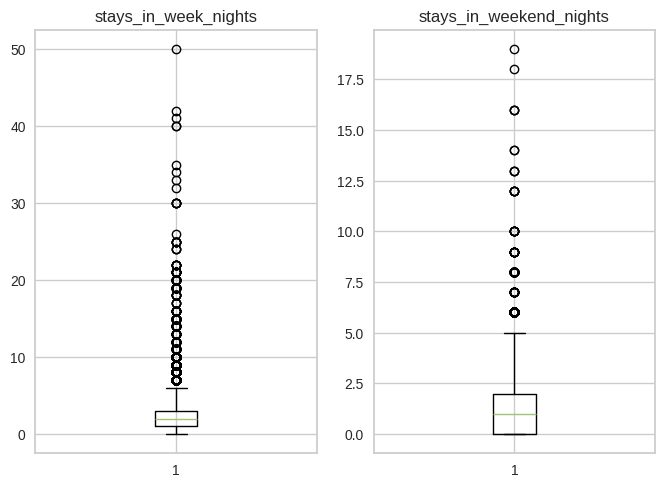

In [18]:
plt.subplot(1, 2, 1)
plt.boxplot(x=data['stays_in_week_nights'])
plt.title('stays_in_week_nights')
plt.subplot(1, 2, 2)
plt.boxplot(x=data['stays_in_weekend_nights'])
plt.title('stays_in_weekend_nights')
plt.show()

In [19]:
q1 = np.quantile(data['stays_in_week_nights'], 0.25)
q3 = np.quantile(data['stays_in_week_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['stays_in_week_nights'] > 6 * upper_lim) | (data['stays_in_week_nights'] < 6 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
9839,1,322,2017,2,10,16,40,2,0.0,0,...,False,False,False,False,False,False,False,False,False,True
14037,0,113,2015,31,1,18,42,1,0.0,0,...,False,False,False,False,False,False,False,False,False,True
14038,0,126,2016,28,5,19,50,1,0.0,0,...,False,False,False,False,False,False,False,False,False,True
33924,0,71,2017,2,10,16,40,2,0.0,0,...,False,False,False,False,True,False,False,False,False,False
101794,0,140,2016,39,22,16,41,0,0.0,0,...,False,False,False,False,True,False,False,False,False,False


In [20]:
data = data[~((data['stays_in_week_nights'] > 6 * upper_lim) | (data['stays_in_week_nights'] < 6 * lower_lim))]

**Handling Outliers**: The 'adr' (Average Daily Rate) column indicates the average transaction price. Extreme outliers (like a single reservation costing over 5000) can severely skew distance-based algorithms like k-NN and SVM. We use the IQR (Interquartile Range) method to identify and remove these extreme anomalies.

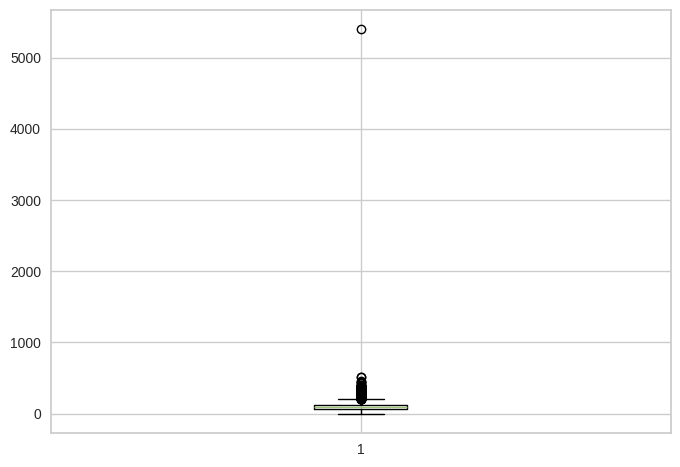

In [21]:
plt.boxplot(x=data['adr'])
plt.show()

In [22]:
q1 = np.quantile(data['adr'], 0.25)
q3 = np.quantile(data['adr'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)

In [23]:
outliers = data[(data['adr'] > 3* upper_lim) | (data['adr'] < 3 * lower_lim)]
outliers

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,country_BRA,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT
48515,1,35,2016,13,25,0,1,2,0.0,0,...,False,False,False,False,False,False,False,False,False,True


In [24]:
data = data[~((data['adr'] > 3 * upper_lim) | (data['adr'] < 3 * lower_lim))]

## EDA

In [ ]:
data_eda = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/hotel_bookings.csv')

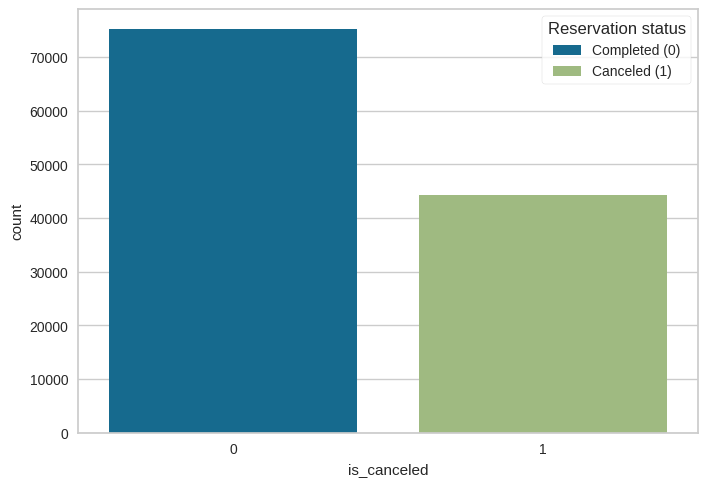

In [ ]:
sns.countplot(data=data, x='is_canceled', hue='is_canceled')
plt.legend(title='Reservation status', labels=['Completed (0)', 'Canceled (1)'], frameon=True)

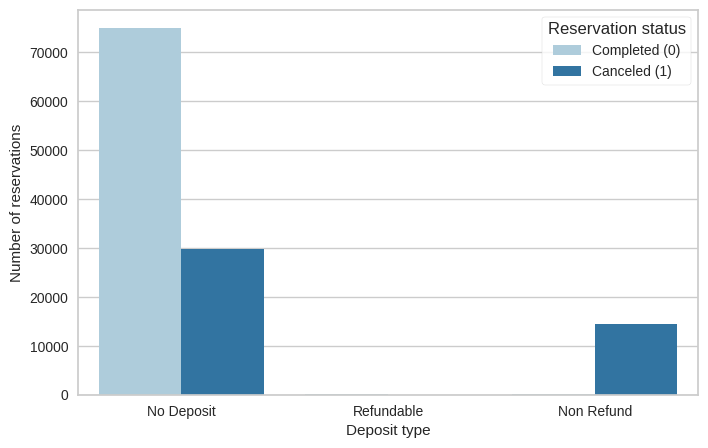

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data_eda, x='deposit_type', hue='is_canceled', palette="Paired")
plt.xlabel('Deposit type')
plt.ylabel('Number of reservations')
plt.legend(title='Reservation status', labels=['Completed (0)', 'Canceled (1)'], frameon=True)
plt.show()

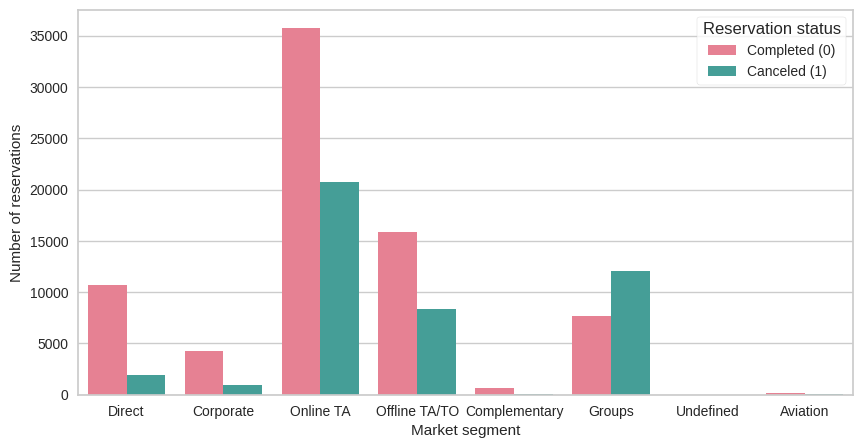

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data_eda, x='market_segment', hue='is_canceled', palette="husl")
plt.xlabel('Market segment')
plt.ylabel('Number of reservations')
plt.legend(title='Reservation status', labels=['Completed (0)', 'Canceled (1)'], frameon=True)
plt.show()

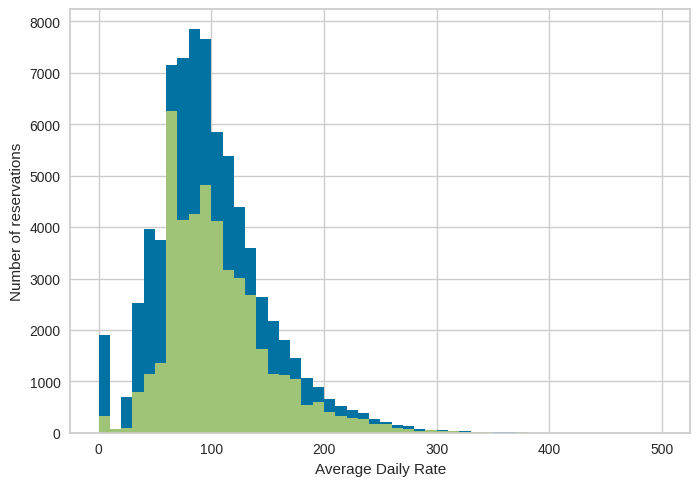

In [ ]:
plt.hist(data[data['is_canceled'] == 0]['adr'], bins=50, range=(0, 500),
         label='Completed (0)', linewidth=2)

plt.hist(data[data['is_canceled'] == 1]['adr'], bins=50, range=(0, 500),
         label='Canceled (1)', linewidth=2)

plt.xlabel("Average Daily Rate")
plt.ylabel("Number of reservations")
plt.show()

## Correlation

In [ ]:
data.corr()['is_canceled'].sort_values(ascending=False).head(7)

,is_canceled
is_canceled,1.000000
deposit_type_Non Refund,0.481450
country_PRT,0.331591
lead_time,0.293123
market_segment_Groups,0.221864
distribution_channel_TA/TO,0.175924
customer_type_Transient,0.133090


In [ ]:
data.corr()['is_canceled'].sort_values(ascending=False).tail(7)

,is_canceled
hotel_Resort Hotel,-0.136525
booking_changes,-0.144468
distribution_channel_Direct,-0.151596
market_segment_Direct,-0.154364
assigned_room_type,-0.165443
required_car_parking_spaces,-0.195504
total_of_special_requests,-0.234625


**Correlation Insights**: By isolating the correlation of all features against our target variable (is_canceled), we can immediately spot the strongest behavioral red flags:

* Top Cancellation Signals (Positive Correlation): deposit_type_Non Refund (0.48), country_PRT (0.33), and lead_time (0.29). Guests booking far in advance or falling under specific deposit types are highly likely to cancel.

* Top Arrival Signals (Negative Correlation): total_of_special_requests (-0.23) and required_car_parking_spaces (-0.19). Guests who take the time to make special requests or reserve parking are highly invested in their trip and rarely cancel.

## PCA

In [25]:
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_train_pca_plot=pca.fit_transform(X_train)
X_train_pca_plot

array([[-1.01757914, -1.38642462,  0.1466669 ],
       [-0.83324476, -1.5077944 ,  0.1626443 ],
       [-0.76717762, -0.83102213,  0.41630631],
       ...,
       [-0.5959185 , -0.24781276,  0.54649751],
       [ 0.31417618, -0.23692631,  0.42223482],
       [ 0.73701998,  0.1903767 ,  0.04158268]])

Text(0, 0.5, 'pc1')

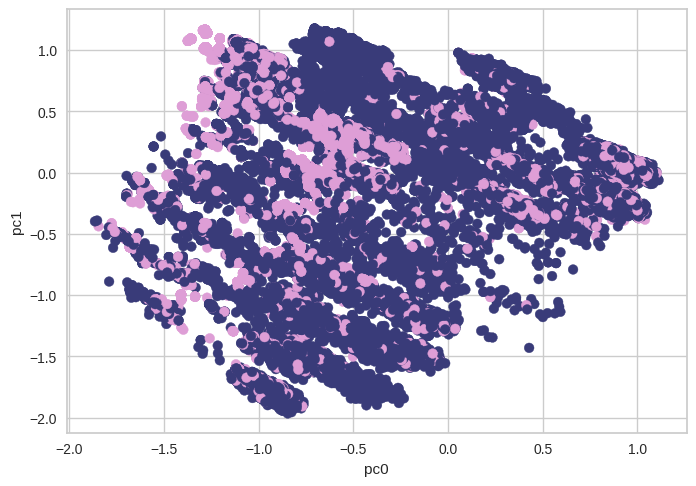

In [ ]:
plt.scatter(X_train_pca_plot[:,0],X_train_pca_plot[:,1], c = y_train, cmap ='tab20b')
plt.xlabel('pc0')
plt.ylabel('pc1')

In [ ]:
components = np.arange(X_train.shape[1] + 1)
var_ratio = []
for num in components:
  if num == 0:
    var_ratio.append(0.0)
    continue
  pca = PCA(n_components=num)
  pca.fit(X_train)
  var_ratio.append(np.sum(pca.explained_variance_ratio_))

Text(0.5, 1.0, 'Number of components and the coefficient of explained variance')

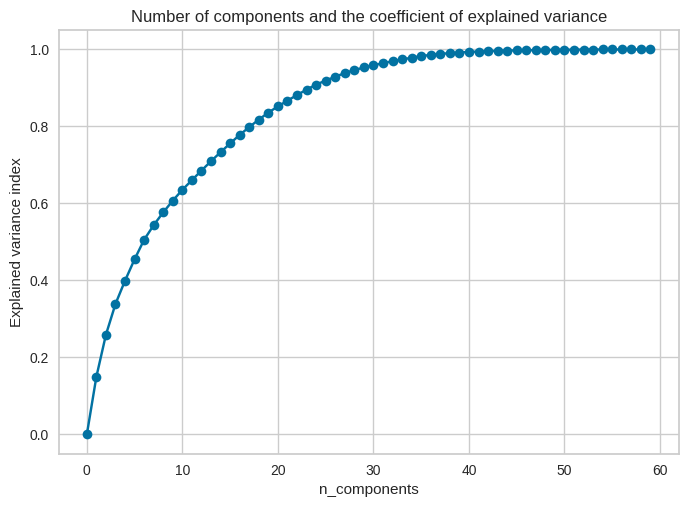

In [ ]:
plt.plot(components,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance index')
plt.title('Number of components and the coefficient of explained variance')

Principal Component Analysis (PCA): PCA was used to reduce the number of variables in the dataset. The analysis showed that the first 40 principal components explained almost all of the statistical variance in the data. While this allows subsequent models to train faster, PCA is an unsupervised technique. As we will see later in the modeling phase, compressing the data this way actually degraded predictive performance, as PCA discarded subtle patterns heavily tied to cancellations.

In [ ]:
pca_40 = PCA(n_components=40)
X_train_pca40 = pca_40.fit_transform(X_train)

X_test_pca40 = pca_40.transform(X_test)

In [ ]:
kolumny_pca = [f'PC{i}' for i in range(1, 41)]
df_train_pca = pd.DataFrame(X_train_pca40, columns=kolumny_pca)

y_train_safe = y_train.reset_index(drop=True)

plik_train = pd.concat([df_train_pca, y_train_safe], axis=1)
plik_train.to_csv('train_pca40.csv', index=False)

In [ ]:
df_test_pca = pd.DataFrame(X_test_pca40, columns=kolumny_pca)
y_test_safe = y_test.reset_index(drop=True)

plik_test = pd.concat([df_test_pca, y_test_safe], axis=1)
plik_test.to_csv('test_pca40.csv', index=False)

The data was saved to a csv file, and then another notebook was created to test how models built on the PCA Reduced Dataset compared to those with the full data.

## t-SNE

In [ ]:
lables = data.columns.values

Due to the high computational complexity of the t-SNE algorithm, the algorithm is performed on a random sample of 25,000 observations to ensure reasonable execution time without losing the general data distribution.

In [ ]:
sample_size = 25000
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = data.loc[X_sample.index, 'is_canceled']


tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', n_jobs=-1)
data_tsne = tsne.fit_transform(X_sample)

data_tsne_df = pd.DataFrame(data_tsne, columns=["tsne_0", "tsne_1"])

In [ ]:
colors, mapping = pd.factorize(y_sample)

<Axes: xlabel='tsne_0', ylabel='tsne_1'>

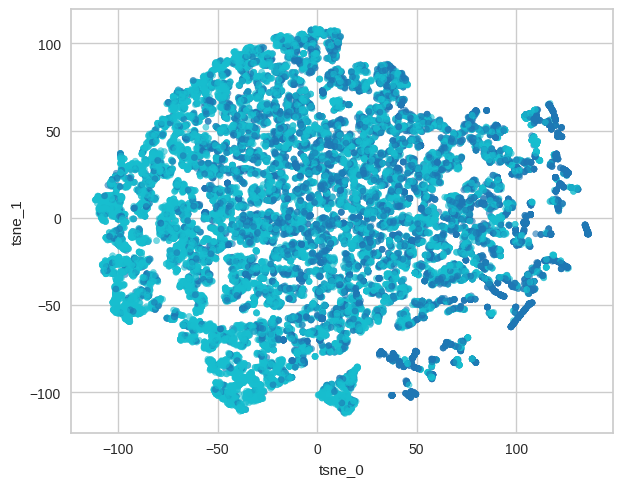

In [ ]:
data_tsne_df.plot.scatter(x="tsne_0", y="tsne_1",
                             c=colors, cmap="tab10", colorbar=False,
                             figsize=(7.0, 5.5), alpha = 0.6)

The light blue and dark blue points (representing canceled and uncanceled reservations from the is_canceled variable) are quite mixed together.

<Axes: xlabel='tsne_0', ylabel='tsne_1'>

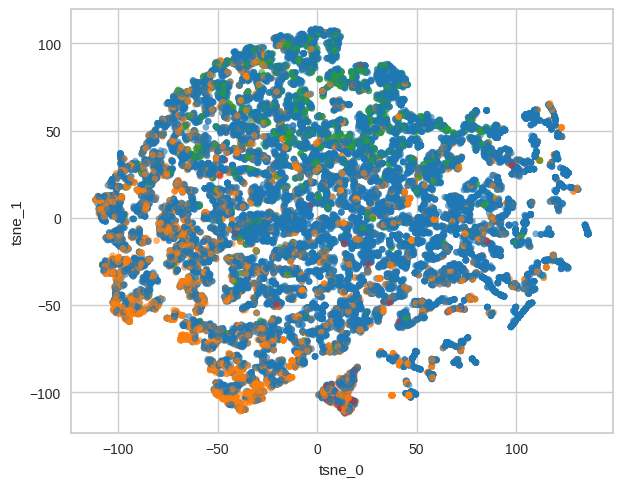

In [ ]:
y_sample = data.loc[X_sample.index, 'adults']
colors, mapping = pd.factorize(y_sample)
data_tsne_df.plot.scatter(x="tsne_0", y="tsne_1",
                             c=colors, cmap="tab10", colorbar=False,
                             figsize=(7.0, 5.5), alpha = 0.6)

## Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8070415456779093


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22549
           1       0.80      0.64      0.71     13267

    accuracy                           0.81     35816
   macro avg       0.81      0.77      0.78     35816
weighted avg       0.81      0.81      0.80     35816



In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)

pipeline_lr = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(max_iter=1000)
)
scores = cross_validate(
    pipeline_lr, X_train_raw, y_train_raw, cv=5, return_train_score=True,
    scoring=("accuracy", "precision", "recall", "f1")
)
scores

{'fit_time': array([3.86407161, 2.96213102, 4.81454706, 2.91662073, 3.55156159]),
 'score_time': array([0.10528016, 0.13648891, 0.09912777, 0.08051658, 0.10164881]),
 'test_accuracy': array([0.80854374, 0.81117626, 0.80387699, 0.80404476, 0.8066176 ]),
 'train_accuracy': array([0.80732641, 0.80692255, 0.80725162, 0.80700022, 0.80658141]),
 'test_precision': array([0.80667078, 0.80525253, 0.79652352, 0.80220695, 0.79745557]),
 'train_precision': array([0.80315687, 0.79972579, 0.80314759, 0.80102977, 0.80300381]),
 'test_recall': array([0.63408318, 0.64519262, 0.63046293, 0.62366462, 0.63920363]),
 'train_recall': array([0.63418582, 0.63727593, 0.63395784, 0.6358192 , 0.63173229]),
 'test_f1': array([0.71003987, 0.71639109, 0.70383086, 0.70175758, 0.70961366]),
 'train_f1': array([0.7087394 , 0.70931856, 0.7085934 , 0.70892644, 0.70714528])}

Conclusions:

* Precision - when the model indicates a class of 1 (canceled), it is correct 80% of the time.

* Recall - of all customers who actually canceled their reservation, the algorithm only caught 63%.

* Accuracy - identical results for train and test, meaning there is no overfitting.

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)
pipeline_lr = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(solver='saga', max_iter=5000,class_weight='balanced', random_state=42)
)
param_grid_lr = {
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': [0.1, 1, 10, 100]
}
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring = 'f1', n_jobs=-1)
grid_lr.fit(X_train_raw, y_train_raw)
print("Best parameters:", grid_lr.best_params_)

Best parameters: {'logisticregression__C': 10, 'logisticregression__penalty': 'l2'}


In [ ]:
lr = LogisticRegression(solver='saga', C=10, penalty='l2', max_iter = 5000,class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8038027697118606


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     22549
           1       0.72      0.78      0.75     13267

    accuracy                           0.80     35816
   macro avg       0.79      0.80      0.79     35816
weighted avg       0.81      0.80      0.81     35816



After applying the selected C and penalty, the results improved but they are not satisfactory.

### Feature Selection (RFE)

Since our dataset has many columns, we will check if we can reduce their number without losing the quality of the model using the Recursive Feature Elimination method. Unlike PCA, RFE is supervised—it actively evaluates features against our target variable and drops only the useless noise. This allowed us to build lighter, faster models that performed just as well as the full-feature dataset.

In [ ]:
from sklearn.feature_selection import RFECV
lr = LogisticRegression(solver='saga', C=10, penalty='l2', max_iter = 5000,class_weight='balanced', random_state=42)

selector = RFECV(lr, step=1, min_features_to_select=1,
                 cv=5, scoring="f1")
selector.fit(X_train,y_train)

RFECV(cv=5,
      estimator=LogisticRegression(C=10, class_weight='balanced', max_iter=5000,
                                   random_state=42, solver='saga'),
      scoring='f1')

In [ ]:
selected_features_df = pd.DataFrame({
    "selected": selector.support_,
    "ranking": selector.ranking_
}, index=X.columns)

In [ ]:
feature_names = selected_features_df[
    selected_features_df["selected"] == True
].index
feature_names

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests', 'has_agent',
       'arrival_date_month_August', 'arrival_date_month_December',
       'arrival_date_month_January', 'arrival_date_month_November',
       'arrival_date_month_October', 'arrival_date_month_September',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'market_segment_Undefined', 'distribution_channel_Direct',
       'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined', 'deposit_type_Non Refund',
       'deposit_type

In [ ]:
dane_rfe = data[feature_names.tolist() + ["is_canceled"]]

dane_rfe.to_csv('data_rfe_selected.csv', index=False)

The data was saved to a CSV file, and then another notebook was created to test how models built on the dataset without the redundant columns compared to the dataset with the full data.

## k-NN

In [ ]:
klasyfikator = KNeighborsClassifier(n_neighbors=3)
klasyfikator.fit(X_train,y_train)
y_pred= klasyfikator.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8222023676569131


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19480  3069]
 [ 3299  9968]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     22549
           1       0.76      0.75      0.76     13267

    accuracy                           0.82     35816
   macro avg       0.81      0.81      0.81     35816
weighted avg       0.82      0.82      0.82     35816



In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
pipeline_knn = make_pipeline(
    MinMaxScaler(),
    KNeighborsClassifier()
)

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [5, 7, 9, 11],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_raw, y_train_raw)

print("Best parameters for KNN:", grid_knn.best_params_)

Best parameters for KNN: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}


In [ ]:
klasyfikator = KNeighborsClassifier(n_neighbors=11,weights='distance', metric = 'manhattan')
klasyfikator.fit(X_train,y_train)
y_pred= klasyfikator.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8450413223140496


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[20052,  2497],
       [ 3053, 10214]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     22549
           1       0.80      0.77      0.79     13267

    accuracy                           0.85     35816
   macro avg       0.84      0.83      0.83     35816
weighted avg       0.84      0.85      0.84     35816



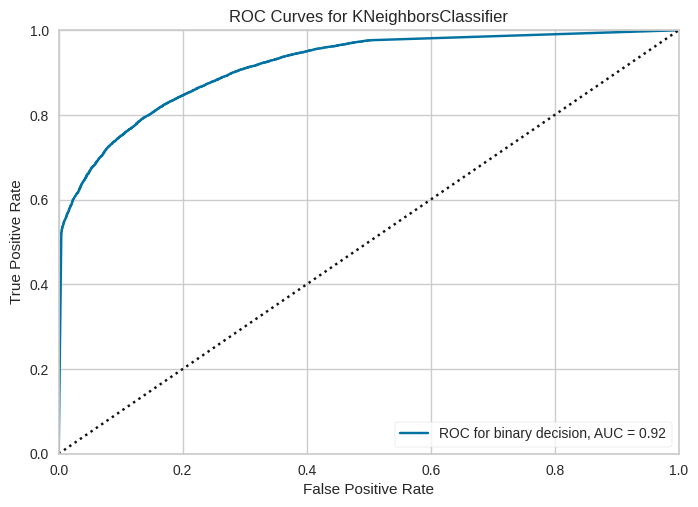

<Axes: title={'center': 'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
vis = ROCAUC(klasyfikator, binary=True)

vis.fit(X_train, y_train)
vis.score(X_test, y_test)
vis.show()

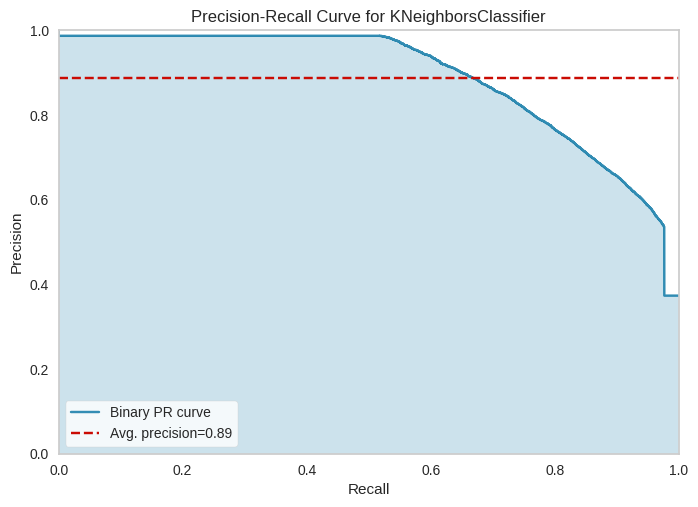

<Axes: title={'center': 'Precision-Recall Curve for KNeighborsClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
viz = PrecisionRecallCurve(klasyfikator)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

## SVM

In [ ]:
svm = SVC(kernel="poly", degree=3, C=10)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8567160845408605

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[20544,  1902],
       [ 3230, 10141]])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     22446
           1       0.84      0.76      0.80     13371

    accuracy                           0.86     35817
   macro avg       0.85      0.84      0.84     35817
weighted avg       0.86      0.86      0.86     35817



In [ ]:
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=20000, stratify=y_train, random_state=42)

pipeline_svc = make_pipeline(
    MinMaxScaler(),
    SVC(class_weight='balanced', probability=True, random_state=42)
)

param_grid_svc = [
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10]},
    {'svc__kernel': ['poly'], 'svc__C': [0.1, 1, 10], 'svc__degree': [2, 3]}
]

grid_svc = GridSearchCV(pipeline_svc, param_grid_svc, cv=3, scoring='f1', n_jobs=-1)
grid_svc.fit(X_sample, y_sample)

print("Best parameters SVC:", grid_svc.best_params_)

Best parameters SVC: {'svc__C': 10, 'svc__kernel': 'rbf'}


In [ ]:
svm = SVC(class_weight='balanced', probability=True, random_state=42,kernel="rbf", C=10)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8432544114362296

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[18951,  3598],
       [ 2016, 11251]])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87     22549
           1       0.76      0.85      0.80     13267

    accuracy                           0.84     35816
   macro avg       0.83      0.84      0.84     35816
weighted avg       0.85      0.84      0.84     35816



In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)

pipeline_svm = make_pipeline(
    MinMaxScaler(),
    SVC(class_weight='balanced', probability=True, random_state=42, kernel="rbf", C=10)
)
scores = cross_validate(
    pipeline_svm, X_train_raw, y_train_raw, cv=3, return_train_score=True,
    scoring=("accuracy", "precision", "recall", "f1")
)
scores

{'fit_time': array([2452.84351158, 2408.9986918 , 2569.04376936]),
 'score_time': array([51.3786242 , 48.96694326, 46.54921842]),
 'test_accuracy': array([0.84236789, 0.84254739, 0.84175761]),
 'train_accuracy': array([0.86331491, 0.86162766, 0.86173535]),
 'test_precision': array([0.75705084, 0.75684366, 0.75548807]),
 'train_precision': array([0.78250838, 0.78073119, 0.78113142]),
 'test_recall': array([0.84461494, 0.84578032, 0.84558609]),
 'train_recall': array([0.87282704, 0.87001068, 0.86962222]),
 'test_f1': array([0.79843929, 0.79884425, 0.79800202]),
 'train_f1': array([0.82520372, 0.82295662, 0.82300499])}

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)

pipeline_svm = make_pipeline(
    MinMaxScaler(),
    SVC(class_weight='balanced', probability=True, random_state=42,kernel="rbf", C=10)
)
scores = cross_validate(
    pipeline_svm, X_train_raw, y_train_raw, cv=3, return_train_score=True,
    scoring=("accuracy", "precision_macro", "recall_macro", "f1_macro")
)
scores

{'fit_time': array([2633.2750802 , 2609.96459556, 2675.8080976 ]),
 'score_time': array([51.75866485, 50.60483932, 49.86070347]),
 'test_accuracy': array([0.84236789, 0.84254739, 0.84175761]),
 'train_accuracy': array([0.86331491, 0.86162766, 0.86173535]),
 'test_precision_macro': array([0.82964956, 0.82985617, 0.82906361]),
 'train_precision_macro': array([0.85125847, 0.84951158, 0.8496171 ]),
 'test_recall_macro': array([0.84283256, 0.84321592, 0.8425493 ]),
 'train_recall_macro': array([0.86528191, 0.86336117, 0.86336627]),
 'test_f1_macro': array([0.83450718, 0.83474712, 0.83396707]),
 'train_f1_macro': array([0.85649287, 0.85469511, 0.85478188])}

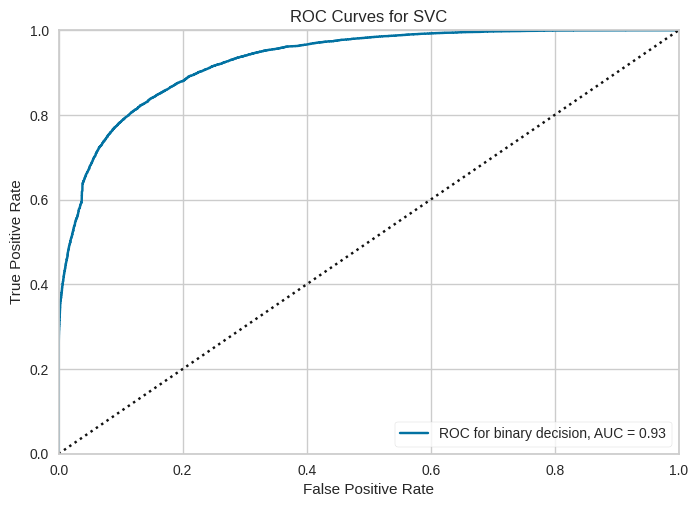

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
vis = ROCAUC(svm, binary=True)

vis.fit(X_train, y_train)
vis.score(X_test, y_test)
vis.show()

## SMOTE

**Handling Class Imbalance (SMOTE)**:  Because our target variable is unbalanced, we used the SMOTE algorithm to artificially generate synthetic Class 1 samples. Crucially, SMOTE was only applied to the training data inside the cross-validation pipeline. This ensures no synthetic data leaked into our validation folds, providing a true, unbiased evaluation of the model's ability to catch rare cancellations.

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, stratify=y random_state=42)
pipeline_knn_smote = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn_smote = GridSearchCV(pipeline_knn_smote, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn_smote.fit(X_train_raw, y_train_raw)

print("Best parameters:", grid_knn_smote.best_params_)

In [ ]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
model = KNeighborsClassifier(n_neighbors=9,weights='distance')
model.fit(X_train_sm, y_train_sm)
y_pred_sm = model.predict(X_test)
print(accuracy_score(y_test, y_pred_sm))

0.8204483904291259


In [ ]:
print(classification_report(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85     22446
           1       0.73      0.83      0.78     13371

    accuracy                           0.82     35817
   macro avg       0.81      0.82      0.81     35817
weighted avg       0.83      0.82      0.82     35817



In [ ]:
cm = confusion_matrix(y_test, y_pred_sm)
print(cm)

[[18302  4144]
 [ 2287 11084]]


In [ ]:
svm = SVC(kernel="poly", degree=3, C=10)
svm.fit(X_train_sm, y_train_sm)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8490660859368456

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[19033,  3413],
       [ 1993, 11378]])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88     22446
           1       0.77      0.85      0.81     13371

    accuracy                           0.85     35817
   macro avg       0.84      0.85      0.84     35817
weighted avg       0.85      0.85      0.85     35817



## Decision Tree

In [29]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_raw, y_train_raw)
y_pred_tree = tree.predict(X_test_raw)
accuracy_score(y_test_raw, y_pred_tree)

0.8475262452535179

In [30]:
print(classification_report(y_test_raw, y_pred_tree))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     22485
           1       0.79      0.80      0.80     13331

    accuracy                           0.85     35816
   macro avg       0.84      0.84      0.84     35816
weighted avg       0.85      0.85      0.85     35816



In [31]:
cm = confusion_matrix(y_test_raw, y_pred_tree)
cm

array([[19684,  2801],
       [ 2660, 10671]])

In [32]:
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='f1', n_jobs=-1)
grid_tree.fit(X_train_raw, y_train_raw)

print("Best parameteres for decision tree:", grid_tree.best_params_)

Best parameteres for decision tree: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'min_samples_split': 2}


In [33]:
tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion= 'gini', max_depth= 20, max_features= None, min_samples_split=2 )
tree.fit(X_train_raw, y_train_raw)
y_pred_tree = tree.predict(X_test_raw)
accuracy_score(y_test_raw, y_pred_tree)

0.8479171320080411

In [34]:
print(classification_report(y_test_raw, y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88     22485
           1       0.77      0.84      0.80     13331

    accuracy                           0.85     35816
   macro avg       0.84      0.85      0.84     35816
weighted avg       0.85      0.85      0.85     35816



In [35]:
cm = confusion_matrix(y_test_raw, y_pred_tree)
cm

array([[19139,  3346],
       [ 2101, 11230]])

## Conclusions

1. Technical Conclusions (Model Evaluation):

* Overall Accuracy (82-85%): The models correctly predict the final booking status in more than 8 out of 10 cases.

* Class Balance: The macro average and weighted average scores are nearly identical. This proves the model is not blindly guessing the majority class (Class 0), but is actively learning the underlying patterns of both classes.


2. ROC and PR Curves Interpretation

* ROC Curve Interpretation:

  * High AUC (0.89 - 0.93): The model is exceptionally good at ranking risk. If we randomly select one canceled booking and one fulfilled booking, there is roughly a 90% chance the model will assign a higher cancellation probability to the correct guest.

  * Automation Potential: Because the model gains sensitivity rapidly with a very slow increase in false alarms, the hotel can confidently automate backend processes (like deposit request emails) for the highest-risk percentiles.

* Precision-Recall (PR) Curve Interpretation:

  * The Trade-off: The PR curve perfectly visualizes the hotel's business options. If the hotel wants to safely overbook, they can set a strict threshold to catch 60-70% of cancellations while maintaining a massive 90% Precision. If they want to aggressively chase down deposits, they can lower the threshold to catch 90% of cancellations, but must accept that Precision will drop to around 70% (meaning more false alarms).